# 🔗 Multivariate Prophet: Adding Regressors

## 1. What are Regressors?
In standard Prophet, the forecast is based purely on time:
$$y(t) = \text{Trend}(t) + \text{Seasonality}(t)$$

When you add a **Regressor** (also called an External Feature), you add a linear component based on another variable $X$:
$$y(t) = \text{Trend}(t) + \text{Seasonality}(t) + \beta \cdot X(t)$$

* **Example:** Predicting *Ice Cream Sales* ($y$).
* **Regressor:** *Temperature* ($X$).
* **Logic:** If Temperature goes up, Sales go up (Coefficient $\beta$ is positive).

## 2. The Golden Rule: "The Future Must Be Known" ⚠️
This is the most critical constraint of `add_regressor`.
**To predict $y$ for next month, you must know the value of $X$ for next month.**

* **Valid Use Case:**
    * **Holidays:** We know when Christmas is next year.
    * **Planned Promotions:** We know we will run a 20% discount next week.
    * **Controlled Variables:** We know our Ad Budget for Q4.
* **Invalid Use Case:**
    * **Stock Price:** You cannot use "Oil Price" to predict "Airline Stock" because you don't know the Oil Price next week! (Unless you forecast Oil Price first, which adds error).

## 3. How to use it
1.  Add the column to your training dataframe.
2.  Call `m.add_regressor('column_name')` **before** fitting.
3.  **Crucial:** When you create the `future` dataframe, you must populate this column with known future values.

#### 1) Importing Necessary Libraries:

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import statsmodels.api as sm

from prophet import Prophet
from prophet.utilities import regressor_coefficients

from sklearn.metrics import mean_absolute_percentage_error

#### 2) Loading Data:

In [2]:
# Using Dataset from Statsmodels:

macro_data = sm.datasets.macrodata.load_pandas().data

In [4]:
macro_data.head()

,year,quarter,realgdp,realcons,realinv,realgovt,realdpi,cpi,m1,tbilrate,unemp,pop,infl,realint
0,1959.0,1.0,2710.349,1707.4,286.898,470.045,1886.9,28.98,139.7,2.82,5.8,177.146,0.00,0.00
1,1959.0,2.0,2778.801,1733.7,310.859,481.301,1919.7,29.15,141.7,3.08,5.1,177.830,2.34,0.74
2,1959.0,3.0,2775.488,1751.8,289.226,491.260,1916.4,29.35,140.5,3.82,5.3,178.657,2.74,1.09
3,1959.0,4.0,2785.204,1753.7,299.356,484.052,1931.3,29.37,140.0,4.33,5.6,179.386,0.27,4.06
4,1960.0,1.0,2847.699,1770.5,331.722,462.199,1955.5,29.54,139.6,3.50,5.2,180.007,2.31,1.19


In [5]:
macro_data.shape

(203, 14)

In [6]:
macro_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 203 entries, 0 to 202
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   year      203 non-null    float64
 1   quarter   203 non-null    float64
 2   realgdp   203 non-null    float64
 3   realcons  203 non-null    float64
 4   realinv   203 non-null    float64
 5   realgovt  203 non-null    float64
 6   realdpi   203 non-null    float64
 7   cpi       203 non-null    float64
 8   m1        203 non-null    float64
 9   tbilrate  203 non-null    float64
 10  unemp     203 non-null    float64
 11  pop       203 non-null    float64
 12  infl      203 non-null    float64
 13  realint   203 non-null    float64
dtypes: float64(14)
memory usage: 22.3 KB


In [8]:
macro_data.describe().T

,count,mean,std,min,25%,50%,75%,max
year,203.0,1983.876847,14.686817,1959.000,1971.0000,1984.000,1996.5000,2009.000
quarter,203.0,2.492611,1.118563,1.000,1.5000,2.000,3.0000,4.000
realgdp,203.0,7221.171901,3214.956044,2710.349,4440.1035,6559.594,9629.3465,13415.266
realcons,203.0,4825.293103,2313.346192,1707.400,2874.1000,4299.900,6398.1500,9363.600
realinv,203.0,1012.863862,585.102267,259.764,519.1475,896.210,1436.6815,2264.721
realgovt,203.0,663.328640,140.863655,460.400,527.9595,662.412,773.0490,1044.088
realdpi,203.0,5310.540887,2423.515977,1886.900,3276.9500,4959.400,6977.8500,10077.500
cpi,203.0,105.075788,61.278878,28.980,41.0500,104.100,159.6500,218.610
m1,203.0,667.927586,455.346381,139.600,228.6500,540.900,1102.1000,1673.900
tbilrate,203.0,5.311773,2.803071,0.120,3.5150,5.010,6.6650,15.330


##### Creating Date column from year and quarter:

In [10]:
macro_data['ds'] = pd.PeriodIndex.from_fields(
    year = macro_data['year'],
    quarter = macro_data['quarter'],
    freq= 'Q'
).to_timestamp()

In [11]:
macro_data.head()

,year,quarter,realgdp,realcons,realinv,realgovt,realdpi,cpi,m1,tbilrate,unemp,pop,infl,realint,ds
0,1959.0,1.0,2710.349,1707.4,286.898,470.045,1886.9,28.98,139.7,2.82,5.8,177.146,0.00,0.00,1959-01-01
1,1959.0,2.0,2778.801,1733.7,310.859,481.301,1919.7,29.15,141.7,3.08,5.1,177.830,2.34,0.74,1959-04-01
2,1959.0,3.0,2775.488,1751.8,289.226,491.260,1916.4,29.35,140.5,3.82,5.3,178.657,2.74,1.09,1959-07-01
3,1959.0,4.0,2785.204,1753.7,299.356,484.052,1931.3,29.37,140.0,4.33,5.6,179.386,0.27,4.06,1959-10-01
4,1960.0,1.0,2847.699,1770.5,331.722,462.199,1955.5,29.54,139.6,3.50,5.2,180.007,2.31,1.19,1960-01-01


##### Creating Dataframe of Date, Regressor and Target Variable:
(We will predict Consumption (y) based on Income (realdpi))

In [14]:
df = macro_data[['ds', 'realcons', 'realdpi']]
df = df.rename(columns= {'realcons': 'y'})

In [15]:
df.head()

,ds,y,realdpi
0,1959-01-01,1707.4,1886.9
1,1959-04-01,1733.7,1919.7
2,1959-07-01,1751.8,1916.4
3,1959-10-01,1753.7,1931.3
4,1960-01-01,1770.5,1955.5


#### 3) Train Test Split:

In [16]:
len(df)

203

In [17]:
train_data = df[:-12]
test_data = df[-12:]
print(train_data.shape, test_data.shape)

(191, 3) (12, 3)


#### 4) Model:

##### Model 1: Baseline (Univariate):

In [19]:
model_base = Prophet() # Model Instance
model_base.fit(train_data) # Fitting Model on Training Data
future_base = model_base.make_future_dataframe(periods= 12, freq= 'QE') # Future Dataframe
forecast_base = model_base.predict(future_base) # Prediction

20:45:19 - cmdstanpy - INFO - Chain [1] start processing
20:45:19 - cmdstanpy - INFO - Chain [1] done processing


In [20]:
forecast_base.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,1959-01-01,1779.354619,1607.628005,1741.040700,1779.354619,1779.354619,-102.390705,-102.390705,-102.390705,-102.390705,-102.390705,-102.390705,0.0,0.0,0.0,1676.963915
1,1959-04-01,1797.043084,1622.706731,1752.791753,1797.043084,1797.043084,-109.143551,-109.143551,-109.143551,-109.143551,-109.143551,-109.143551,0.0,0.0,0.0,1687.899533
2,1959-07-01,1814.928086,1644.410625,1773.613646,1814.928086,1814.928086,-104.163902,-104.163902,-104.163902,-104.163902,-104.163902,-104.163902,0.0,0.0,0.0,1710.764184
3,1959-10-01,1833.009628,1654.680565,1782.957048,1833.009628,1833.009628,-114.912404,-114.912404,-114.912404,-114.912404,-114.912404,-114.912404,0.0,0.0,0.0,1718.097223
4,1960-01-01,1851.091169,1673.339408,1808.143357,1851.091169,1851.091169,-107.301731,-107.301731,-107.301731,-107.301731,-107.301731,-107.301731,0.0,0.0,0.0,1743.789437


In [21]:
forecast_base.tail()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
198,2008-06-30,9804.583223,9620.941541,9771.044499,9773.652443,9835.497301,-108.740278,-108.740278,-108.740278,-108.740278,-108.740278,-108.740278,0.0,0.0,0.0,9695.842944
199,2008-09-30,9874.429706,9674.111384,9824.304112,9836.937516,9912.869929,-125.397602,-125.397602,-125.397602,-125.397602,-125.397602,-125.397602,0.0,0.0,0.0,9749.032104
200,2008-12-31,9944.276190,9751.465477,9918.283843,9898.348751,9988.805494,-111.652566,-111.652566,-111.652566,-111.652566,-111.652566,-111.652566,0.0,0.0,0.0,9832.623623
201,2009-03-31,10012.604271,9801.677784,9985.619846,9959.093262,10065.076146,-121.073281,-121.073281,-121.073281,-121.073281,-121.073281,-121.073281,0.0,0.0,0.0,9891.530990
202,2009-06-30,10081.691553,9869.576051,10062.901590,10019.286313,10142.587465,-113.129488,-113.129488,-113.129488,-113.129488,-113.129488,-113.129488,0.0,0.0,0.0,9968.562065


##### Model 2: Multivariate (With Regressor):

In [22]:
model_reg = Prophet() # Model Instance
model_reg.add_regressor('realdpi') # Adding Regressor
model_reg.fit(train_data) # Fitting Model on Training Data
future_reg = model_reg.make_future_dataframe(periods= 12, freq= 'QE') # Future Dataframe

20:48:37 - cmdstanpy - INFO - Chain [1] start processing
20:48:37 - cmdstanpy - INFO - Chain [1] done processing


- We must add the future 'realdpi' values to the future dataframe.
- In a real business case, this would be our "Budgeted Income" or "Planned Spend".
- Here, we cheat slightly by using the actuals from test_df to show potential accuracy.

In [26]:
future_reg['realdpi'] = pd.concat([train_data['realdpi'], test_data['realdpi']]).values

In [27]:
future_reg.head()

,ds,realdpi
0,1959-01-01,1886.9
1,1959-04-01,1919.7
2,1959-07-01,1916.4
3,1959-10-01,1931.3
4,1960-01-01,1955.5


In [28]:
future_reg.tail()

,ds,realdpi
198,2008-06-30,9838.3
199,2008-09-30,9920.4
200,2008-12-31,9926.4
201,2009-03-31,10077.5
202,2009-06-30,10040.6


In [29]:
# Prediction
forecast_reg = model_reg.predict(future_reg)

In [30]:
forecast_reg.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,extra_regressors_additive,extra_regressors_additive_lower,extra_regressors_additive_upper,realdpi,realdpi_lower,realdpi_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,1959-01-01,2603.240215,1655.936804,1749.688166,2603.240215,2603.240215,-900.968198,-900.968198,-900.968198,-2190.828678,-2190.828678,-2190.828678,-2190.828678,-2190.828678,-2190.828678,1289.860480,1289.860480,1289.860480,0.0,0.0,0.0,1702.272017
1,1959-04-01,2606.195238,1682.262873,1771.933570,2606.195238,2606.195238,-880.079934,-880.079934,-880.079934,-2167.904643,-2167.904643,-2167.904643,-2167.904643,-2167.904643,-2167.904643,1287.824709,1287.824709,1287.824709,0.0,0.0,0.0,1726.115304
2,1959-07-01,2609.183096,1689.765389,1783.421884,2609.183096,2609.183096,-871.246668,-871.246668,-871.246668,-2170.211025,-2170.211025,-2170.211025,-2170.211025,-2170.211025,-2170.211025,1298.964357,1298.964357,1298.964357,0.0,0.0,0.0,1737.936428
3,1959-10-01,2612.203786,1697.466156,1790.533766,2612.203786,2612.203786,-869.020568,-869.020568,-869.020568,-2159.797362,-2159.797362,-2159.797362,-2159.797362,-2159.797362,-2159.797362,1290.776794,1290.776794,1290.776794,0.0,0.0,0.0,1743.183218
4,1960-01-01,2615.224477,1705.428775,1801.758464,2615.224477,2615.224477,-859.420787,-859.420787,-859.420787,-2142.883897,-2142.883897,-2142.883897,-2142.883897,-2142.883897,-2142.883897,1283.463110,1283.463110,1283.463110,0.0,0.0,0.0,1755.803690


In [31]:
forecast_reg.tail()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,extra_regressors_additive,extra_regressors_additive_lower,extra_regressors_additive_upper,realdpi,realdpi_lower,realdpi_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
198,2008-06-30,4759.398606,9380.130903,9477.023523,4745.910139,4774.224395,4667.264438,4667.264438,4667.264438,3366.432681,3366.432681,3366.432681,3366.432681,3366.432681,3366.432681,1300.831757,1300.831757,1300.831757,0.0,0.0,0.0,9426.663044
199,2008-09-30,4781.210716,9442.478497,9546.232944,4764.528992,4799.587105,4711.466261,4711.466261,4711.466261,3423.812659,3423.812659,3423.812659,3423.812659,3423.812659,3423.812659,1287.653602,1287.653602,1287.653602,0.0,0.0,0.0,9492.676978
200,2008-12-31,4803.022826,9454.191878,9560.557962,4782.906696,4825.426086,4705.030028,4705.030028,4705.030028,3428.006080,3428.006080,3428.006080,3428.006080,3428.006080,3428.006080,1277.023948,1277.023948,1277.023948,0.0,0.0,0.0,9508.052854
201,2009-03-31,4824.360760,9581.446316,9694.669855,4798.778822,4851.680930,4811.271728,4811.271728,4811.271728,3533.610400,3533.610400,3533.610400,3533.610400,3533.610400,3533.610400,1277.661328,1277.661328,1277.661328,0.0,0.0,0.0,9635.632488
202,2009-06-30,4845.935782,9599.569663,9718.820027,4816.317293,4878.672140,4809.989875,4809.989875,4809.989875,3507.820861,3507.820861,3507.820861,3507.820861,3507.820861,3507.820861,1302.169014,1302.169014,1302.169014,0.0,0.0,0.0,9655.925656


##### Visualization:

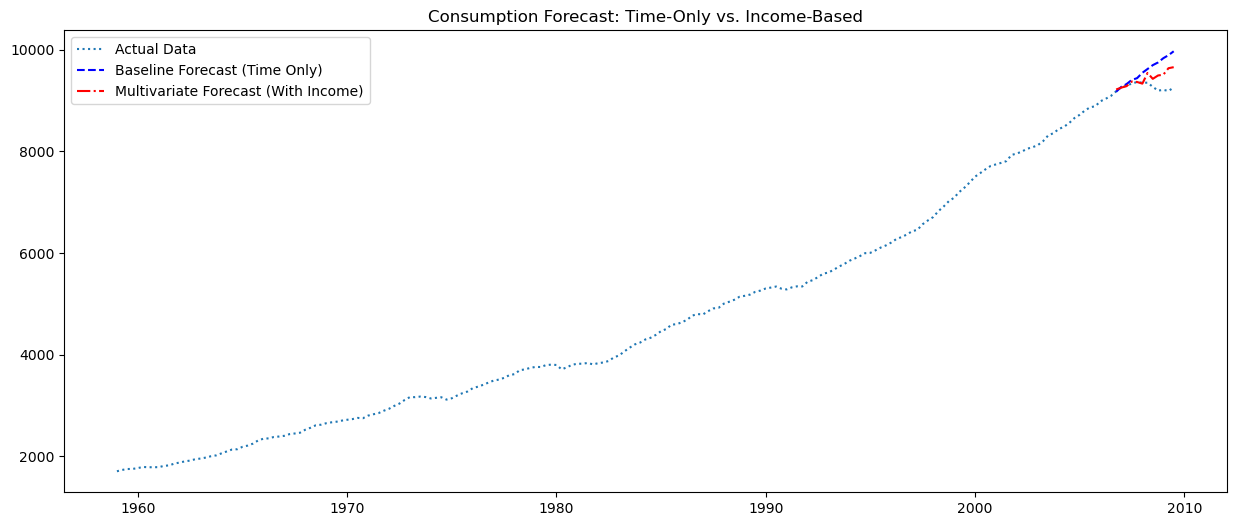

In [38]:
fig, ax = plt.subplots(figsize= (15,6))

# Actual Data:
ax.plot(df['ds'], df['y'], linestyle= ':', label= 'Actual Data')

# Baseline Forecast:
ax.plot(forecast_base['ds'].iloc[-12:],
       forecast_base['yhat'].iloc[-12:],
       color= 'blue',
       label= 'Baseline Forecast (Time Only)',
       linestyle= '--')

# Multivariate Forecast:
ax.plot(forecast_reg['ds'].iloc[-12:],
       forecast_reg['yhat'].iloc[-12:],
       color= 'red',
       label= 'Multivariate Forecast (With Income)',
       linestyle= '-.')

ax.set_title('Consumption Forecast: Time-Only vs. Income-Based')
ax.legend()
plt.show()

#### 5) Quantifying Impact of Regressor:

In [39]:
coeffs = regressor_coefficients(model_reg)
print('\n--- Regressor Impact ---')
print(coeffs)


--- Regressor Impact ---
  regressor regressor_mode       center  coef_lower      coef  coef_upper
0   realdpi       additive  5021.565445    0.698904  0.698904    0.698904


#### 6) Model Evaluation:

In [42]:
mape_base = mean_absolute_percentage_error(test_data['y'], forecast_base['yhat'].iloc[-12:])
mape_reg = mean_absolute_percentage_error(test_data['y'], forecast_reg['yhat'].iloc[-12:])

In [43]:
print(f'\nBaseline MAPE: {mape_base:.4f} ({mape_base*100:.2f}%)')
print(f'Regressor MAPE: {mape_reg:.4f} ({mape_reg*100:.2f}%)')


Baseline MAPE: 0.0332 (3.32%)
Regressor MAPE: 0.0172 (1.72%)
